# 은평구 스테이션 수요 예측 분석

이 노트북은 선택한 스테이션의 시간대별 대여 수요를 예측하기 위한 데이터 준비, 전처리 점검, 피처엔지니어링, 모델 비교, 추천 모델 해석 순서로 구성되어 있습니다.


## 1. 환경 설정


In [1]:
import pandas as pd
import numpy as np
import warnings 
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

## 2. 데이터 로드


In [2]:
df2024 = pd.read_csv('../../Data/Zero/2024_data.csv')
df2025 = pd.read_csv('../../Data/Zero/2025_data.csv')
station_meta = pd.read_csv('../../Data/은평구_스테이션_군집화_1차_자전거댓수_추가.csv', encoding='utf-8-sig')
station_meta = station_meta[[
    '대여소_ID', '위도', '경도', 'cluster_12_custom', 'LCD', 'QR'
]].rename(columns={'대여소_ID': '시작_대여소_ID'})
for col in ['위도', '경도', 'cluster_12_custom', 'LCD', 'QR']:
    station_meta[col] = pd.to_numeric(station_meta[col], errors='coerce')

df = pd.concat([df2024,df2025],axis=0)
kr = holidays.KR()

## 3. 분석 대상 스테이션

- `ST-464`, `ST-481`, `ST-479`
- `ST-2247`, `ST-2252`, `ST-2425`
- `ST-1027`, `ST-2263`, `ST-3126`
- `ST-1035`, `ST-454`, `ST-471`
- `ST-1024`, `ST-1023`, `ST-450`
- `ST-1034`, `ST-462`, `ST-2264`

현재 실제 분석 대상은 바로 아래 `target_station` 셀 값을 기준으로 결정됩니다.


## 4. 원본 데이터 전처리 및 품질 점검


## 전처리 점검 요약

아래 셀들은 최종 모델링 전에 데이터 품질과 전처리 상태를 점검하기 위한 셀입니다.

- 원본 데이터에서 중복 여부를 확인합니다.
- 주요 컬럼의 결측치를 확인합니다.
- 타깃 컬럼의 분포와 이상치 수준을 확인합니다.
- `cluster_12_custom`을 숫자형 그대로 둘 때와 원핫인코딩할 때를 비교합니다.
- 마지막에 최종 권장 파이프라인을 문장으로 요약합니다.

In [3]:
# 원본 데이터 품질 점검: 중복 / 결측 / 타깃 분포
raw_duplicate_count = df.duplicated().sum()
key_duplicate_count = df.duplicated(subset=['기준_날짜', '시간대', '시작_대여소_ID', '종료_대여소_ID']).sum()

raw_quality_df = pd.DataFrame({
    '항목': [
        '원본 전체 행 수',
        '완전 중복 행 수',
        '핵심 키 기준 중복 행 수',
        '전체_건수 결측 수',
        '온도 결측 수',
        '습도 결측 수',
        '강수량 결측 수',
        '적설량 결측 수'
    ],
    '값': [
        len(df),
        int(raw_duplicate_count),
        int(key_duplicate_count),
        int(df['전체_건수'].isna().sum()),
        int(df['온도'].isna().sum()),
        int(df['습도'].isna().sum()),
        int(df['강수량'].isna().sum()),
        int(df['적설량'].isna().sum())
    ]
})

target_summary_df = df['전체_건수'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame(name='전체_건수').reset_index()

display(raw_quality_df)
display(target_summary_df)

,항목,값
0,원본 전체 행 수,347282
1,완전 중복 행 수,161864
2,핵심 키 기준 중복 행 수,180787
3,전체_건수 결측 수,0
4,온도 결측 수,0
5,습도 결측 수,0
6,강수량 결측 수,0
7,적설량 결측 수,0


,index,전체_건수
0,count,347282.000000
1,mean,1.047716
2,std,0.231629
3,min,1.000000
4,50%,1.000000
5,90%,1.000000
6,95%,1.000000
7,99%,2.000000
8,max,7.000000


## 5. 패널 데이터 생성 및 피처엔지니어링


In [4]:
# 1. 시작 대여소 기준으로만 필터링 (순수 대여량 예측 목적)
target_station = ['ST-464', 'ST-481', 'ST-479', 'ST-2247', 'ST-2252', 'ST-2425', 'ST-1027', 'ST-2263', 'ST-3126', 'ST-1035', 'ST-454', 'ST-471', 'ST-1024', 'ST-1023', 'ST-450','ST-1034', 'ST-462', 'ST-2264']
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
df['year'] = df['기준_날짜'].dt.year
df['weekday'] = df['기준_날짜'].dt.dayofweek
df['day_type'] = np.where(df['weekday'] < 5, 0, 1)
df = df[(df['전체_이용_분'] >= 5) & (df['전체_이용_거리'] >= 5)]
df['datetime'] = pd.to_datetime(df['기준_날짜']) + pd.to_timedelta(df['시간대'], unit='h')
df = df[df['시작_대여소_ID'].isin(target_station)].copy()
df_hourly = df.groupby(['시작_대여소_ID', 'datetime','year']).agg({
    '전체_건수': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '불쾌지수': 'mean',
    '강수량': 'mean',
    '적설량': 'mean'
}).reset_index()


In [5]:
# 1. 시간대와 요일 정보 다시 추출
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = np.where(df_hourly['weekday'] < 5, 0, 1)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)

# 반드시 대여소별로 정렬 후 계산해야 데이터가 꼬이지 않습니다.
df_hourly = df_hourly.sort_values(['시작_대여소_ID', 'datetime'])

# lag 피처는 전체 시간축을 채운 뒤 다시 계산합니다.
base_features = [
    'hour',        # 몇 시인지 (가장 중요!)
    'weekday',     # 무슨 요일인지
    'is_weekend',  # 평일/주말
    '온도', '습도', '불쾌지수', '강수량', '적설량',
    '위도', '경도', 'cluster_12_custom', 'LCD', 'QR',
]

lag_features = [
    'lag_1h', 'lag_2h', 'lag_24h', 'rolling_3h',
    'hour_sin',
    'hour_cos',
    'is_holiday'
]

station_profile_features = [
    'station_mean_count', 'station_std_count',
    'station_weekday_mean_count', 'station_weekend_mean_count'
]

In [6]:
# 1. 모든 대여소와 모든 시간대의 조합을 만듭니다.
if df_hourly.empty or df_hourly['datetime'].notna().sum() == 0:
    raise ValueError('df_hourly의 datetime 컬럼이 비어 있습니다. 기준_날짜/시간대 변환 또는 이전 dropna 결과를 확인하세요.')

all_stations = df_hourly['시작_대여소_ID'].unique()
all_times = pd.date_range(start=df_hourly['datetime'].min(), 
                          end=df_hourly['datetime'].max(), 
                          freq='h')

# 2. 빈 데이터프레임 생성
multi_idx = pd.MultiIndex.from_product([all_stations, all_times], 
                                       names=['시작_대여소_ID', 'datetime'])
df_full = pd.DataFrame(index=multi_idx).reset_index()

# 3. 기존 데이터와 결합
df_hourly = pd.merge(df_full, df_hourly, on=['시작_대여소_ID', 'datetime'], how='left')

# 4. 빈 값 처리
df_hourly['전체_건수'] = df_hourly['전체_건수'].fillna(0) # 대여 없는 시간은 0건
df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly = df_hourly.merge(station_meta, on='시작_대여소_ID', how='left')
# 날씨 데이터는 직전 시간 값을 채우거나 평균값으로 채움
df_hourly[['온도', '습도', '불쾌지수', '강수량', '적설량']] = \
    df_hourly.groupby('시작_대여소_ID')[['온도', '습도', '불쾌지수', '강수량', '적설량']].ffill()

df_hourly[['온도', '습도', '불쾌지수', '강수량', '적설량']] = \
    df_hourly.groupby('시작_대여소_ID')[['온도', '습도', '불쾌지수', '강수량', '적설량']].bfill()

df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = np.where(df_hourly['weekday'] < 5, 0, 1)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)
df_hourly = df_hourly.sort_values(['시작_대여소_ID', 'datetime'])

# 전체 시간축 기준으로 lag/rolling 재계산
df_hourly['lag_1h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(1)
df_hourly['lag_2h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(2)
df_hourly['lag_24h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(24)
df_hourly['rolling_3h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].transform(lambda x: x.shift(1).rolling(3).mean())
df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly['hour'] / 24)
df_hourly = df_hourly.dropna(subset=['lag_1h', 'lag_2h', 'lag_24h', 'rolling_3h'])

,항목,값
0,패널 전체 행 수,315360.000000
1,시작_대여소 수,18.000000
2,datetime 결측 수,0.000000
3,lag_1h 결측 수,0.000000
4,lag_24h 결측 수,0.000000
5,rolling_3h 결측 수,0.000000
6,전체_건수 평균,0.712757
7,전체_건수 99% 분위수,12.000000


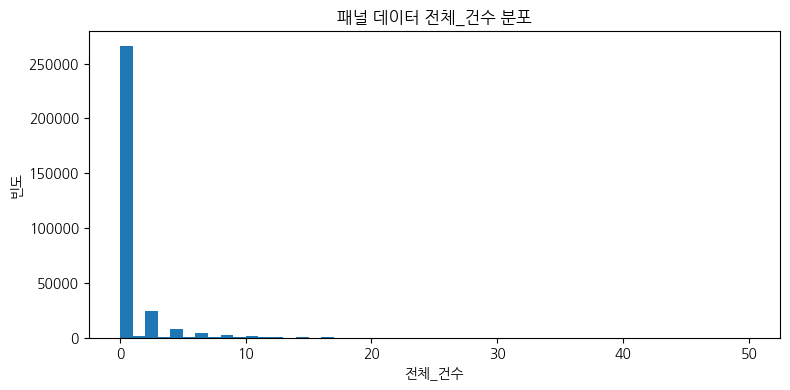

In [7]:
# 패널 데이터 품질 점검: 모델 입력 직전 상태 확인
panel_quality_df = pd.DataFrame({
    '항목': [
        '패널 전체 행 수',
        '시작_대여소 수',
        'datetime 결측 수',
        'lag_1h 결측 수',
        'lag_24h 결측 수',
        'rolling_3h 결측 수',
        '전체_건수 평균',
        '전체_건수 99% 분위수'
    ],
    '값': [
        len(df_hourly),
        df_hourly['시작_대여소_ID'].nunique(),
        int(df_hourly['datetime'].isna().sum()),
        int(df_hourly['lag_1h'].isna().sum()),
        int(df_hourly['lag_24h'].isna().sum()),
        int(df_hourly['rolling_3h'].isna().sum()),
        float(df_hourly['전체_건수'].mean()),
        float(df_hourly['전체_건수'].quantile(0.99))
    ]
})

display(panel_quality_df)

plt.figure(figsize=(8, 4))
plt.hist(df_hourly['전체_건수'], bins=50)
plt.title('패널 데이터 전체_건수 분포')
plt.xlabel('전체_건수')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

## 6. 기본 모델 학습 설정


In [8]:
target = '전체_건수'
# features = [
#     '온도',
#     '습도',
#     '불쾌지수',
#     '강수량',
#     '적설량',
# ]

In [9]:
train = df_hourly[df_hourly['year'] == 2024]
test  = df_hourly[df_hourly['year'] == 2025]

# 스테이션 ID 대신 2024년 기준 스테이션 프로필 피처를 부여
train_profile = train.copy()
train_profile['weekday_target'] = train_profile['전체_건수'].where(train_profile['is_weekend'] == 0)
train_profile['weekend_target'] = train_profile['전체_건수'].where(train_profile['is_weekend'] == 1)

station_profile = train_profile.groupby('시작_대여소_ID', as_index=False).agg({
    '전체_건수': 'mean',
    'weekday_target': 'mean',
    'weekend_target': 'mean'
})
station_profile.columns = [
    '시작_대여소_ID', 'station_mean_count', 'station_weekday_mean_count', 'station_weekend_mean_count'
]
station_std = train.groupby('시작_대여소_ID')['전체_건수'].std().reset_index(name='station_std_count')
station_profile = station_profile.merge(station_std, on='시작_대여소_ID', how='left')
station_profile = station_profile.fillna(0)

train = train.merge(station_profile, on='시작_대여소_ID', how='left')
test = test.merge(station_profile, on='시작_대여소_ID', how='left')

features = base_features + lag_features + station_profile_features

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=600,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

# hgb.fit(X_train, y_train)
# pred_hgb = hgb.predict(X_test)
# print("HGB MAE:", mean_absolute_error(y_test, pred_hgb))
# print("HGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_hgb)))
# print("HGB R2:", r2_score(y_test, pred_hgb))
# 학습할 때
hgb.fit(X_train, np.log1p(y_train))

# 예측할 때 (다시 원래 숫자로 복원)
pred_log = hgb.predict(X_test)
pred_hgb = np.expm1(pred_log)

print("HGB MAE:", mean_absolute_error(y_test, pred_hgb))
print("HGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_hgb)))
print("HGB R2:", r2_score(y_test, pred_hgb))


HGB MAE: 0.4647603884653609
HGB RMSE: 1.260431541389318
HGB R2: 0.6723232225989076


## 7. 기본 모델 검증


In [10]:
# 데이터 검증: 학습/평가에 쓰인 hourly 데이터 상태 확인
validation_summary = pd.DataFrame({
    '항목': ['전체 행 수', 'datetime 결측 수', '대여소 수', '2024 행 수', '2025 행 수', '전체_건수 평균'],
    '값': [
        len(df_hourly),
        int(df_hourly['datetime'].isna().sum()),
        df_hourly['시작_대여소_ID'].nunique(),
        len(train),
        len(test),
        float(df_hourly['전체_건수'].mean()),
    ]
})

display(validation_summary)
display(df_hourly[['datetime', '시작_대여소_ID', '전체_건수']].head())

,항목,값
0,전체 행 수,315360.000000
1,datetime 결측 수,0.000000
2,대여소 수,18.000000
3,2024 행 수,157680.000000
4,2025 행 수,157680.000000
5,전체_건수 평균,0.712757


,datetime,시작_대여소_ID,전체_건수
24,2024-01-02 00:00:00,ST-1023,0.0
25,2024-01-02 01:00:00,ST-1023,0.0
26,2024-01-02 02:00:00,ST-1023,0.0
27,2024-01-02 03:00:00,ST-1023,0.0
28,2024-01-02 04:00:00,ST-1023,0.0


In [11]:
# 모델 검증 1: persistence baseline(직전 1시간 값)과 비교
baseline_pred = test['lag_1h'].fillna(0).clip(lower=0)

comparison_df = pd.DataFrame({
    '모델': ['Persistence Baseline', 'HistGradientBoosting'],
    'MAE': [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, pred_hgb),
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, baseline_pred)),
        np.sqrt(mean_squared_error(y_test, pred_hgb)),
    ],
    'R2': [
        r2_score(y_test, baseline_pred),
        r2_score(y_test, pred_hgb),
    ]
})

display(comparison_df)

,모델,MAE,RMSE,R2
0,Persistence Baseline,0.596715,1.751596,0.367188
1,HistGradientBoosting,0.464760,1.260432,0.672323


In [12]:
# 모델 검증 2: 대여소별 성능과 시간대별 오차 확인
test_result = test[['시작_대여소_ID', 'datetime', 'hour', '전체_건수']].copy()
test_result['예측_건수'] = pred_hgb
test_result['절대오차'] = (test_result['전체_건수'] - test_result['예측_건수']).abs()

station_eval = test_result.groupby('시작_대여소_ID', as_index=False).agg({
    '전체_건수': 'mean',
    '예측_건수': 'mean',
    '절대오차': 'mean'
}).sort_values('절대오차', ascending=False)

hour_eval = test_result.groupby('hour', as_index=False).agg({
    '절대오차': 'mean',
    '전체_건수': 'mean',
    '예측_건수': 'mean'
})

display(station_eval)
display(hour_eval)

,시작_대여소_ID,전체_건수,예측_건수,절대오차
12,ST-454,5.572831,5.185268,2.709118
4,ST-1035,2.658333,2.151278,1.762630
15,ST-471,1.103539,0.838350,1.077478
17,ST-481,0.670548,0.501017,0.737255
16,ST-479,0.422374,0.289279,0.528281
8,ST-2264,0.368721,0.239471,0.477174
14,ST-464,0.245205,0.146498,0.332294
13,ST-462,0.109817,0.104995,0.190534
7,ST-2263,0.089498,0.057980,0.139133
2,ST-1027,0.086416,0.040326,0.118910


,hour,절대오차,전체_건수,예측_건수
0,0,0.481066,0.674734,0.552699
1,1,0.342997,0.445814,0.359883
2,2,0.270518,0.279300,0.264302
3,3,0.212484,0.208219,0.131830
4,4,0.145469,0.103653,0.090902
5,5,0.176130,0.139574,0.086171
6,6,0.287726,0.244597,0.189548
7,7,0.485541,0.496651,0.371286
8,8,0.628323,0.830137,0.575534
9,9,0.383502,0.428615,0.316000


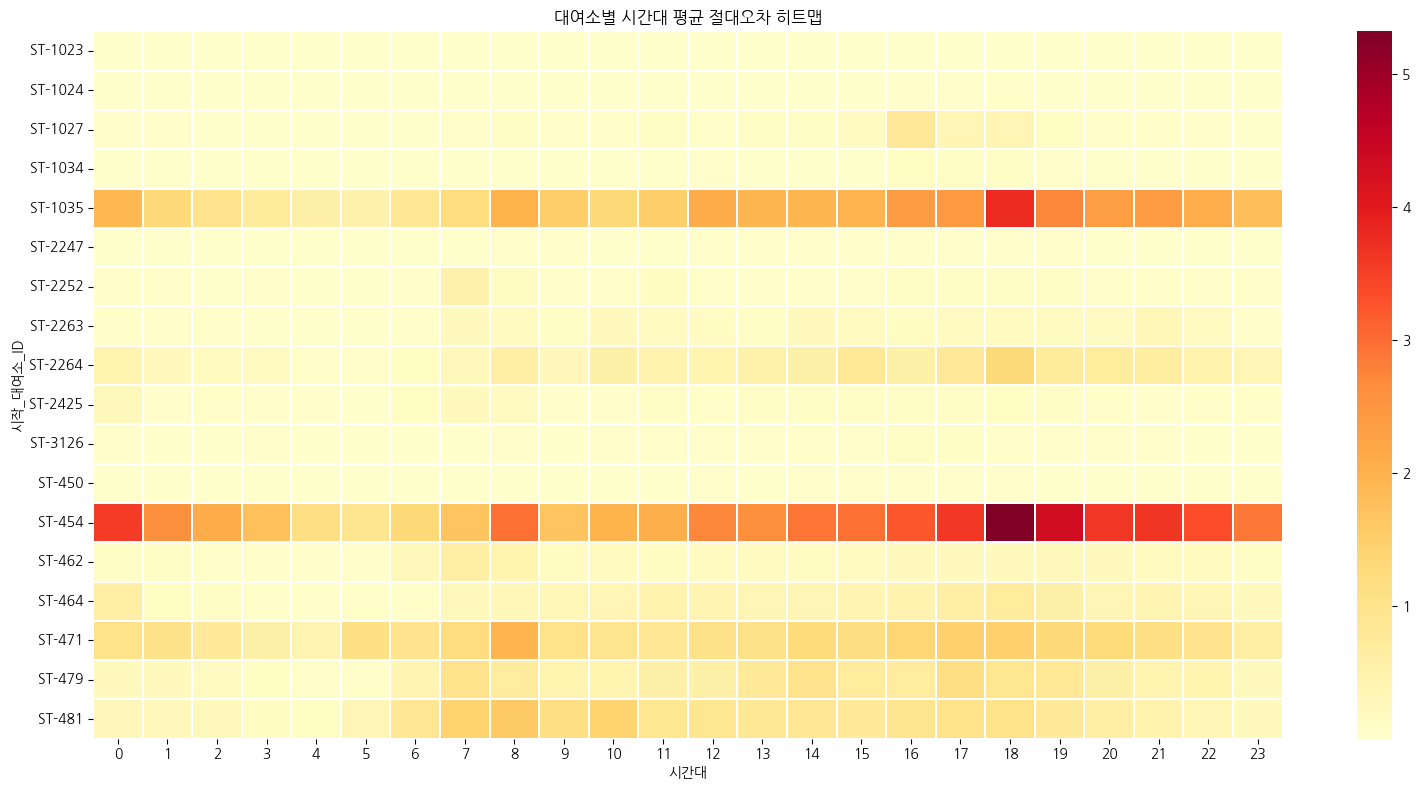

In [13]:
import seaborn as sns

# 시각화 1: 대여소-시간대 평균 절대오차 히트맵
station_hour_error = test_result.groupby(['시작_대여소_ID', 'hour'])['절대오차'].mean().reset_index()
station_hour_pivot = station_hour_error.pivot(index='시작_대여소_ID', columns='hour', values='절대오차')

plt.figure(figsize=(16, 8))
sns.heatmap(station_hour_pivot, cmap='YlOrRd', linewidths=0.2)
plt.title('대여소별 시간대 평균 절대오차 히트맵')
plt.xlabel('시간대')
plt.ylabel('시작_대여소_ID')
plt.tight_layout()
plt.show()

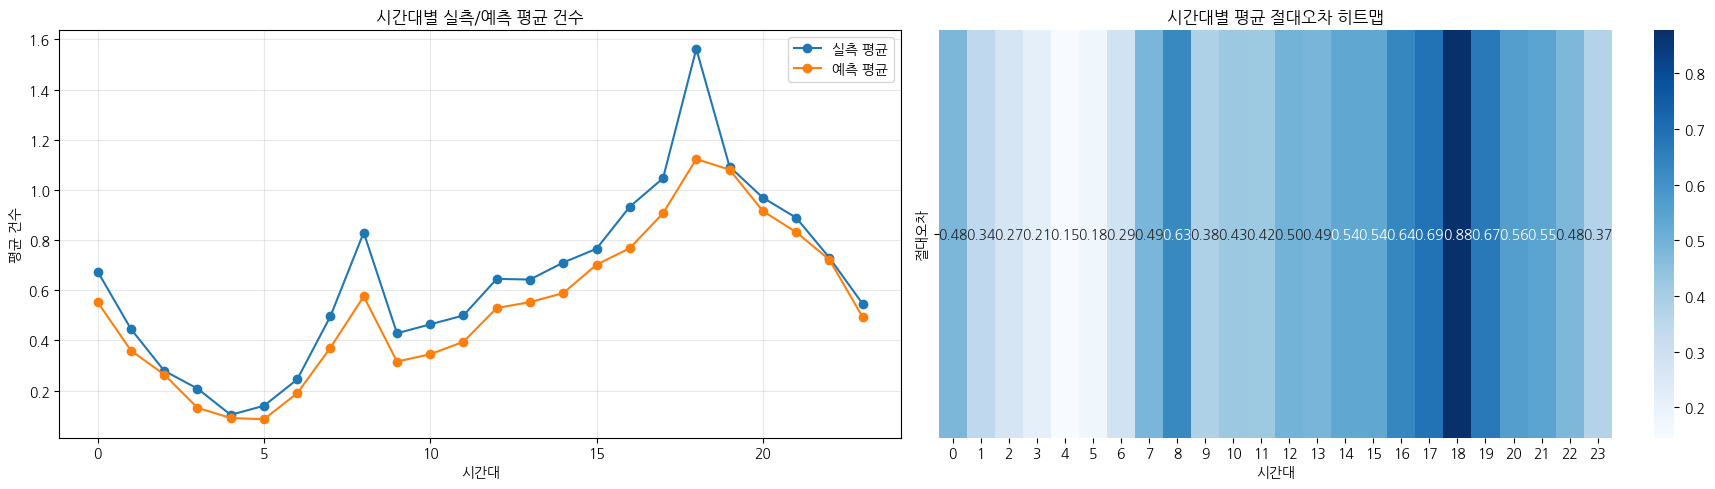

In [14]:
# 시각화 2: 시간대별 실측/예측 평균 비교 + 절대오차 히트맵
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(hour_eval['hour'], hour_eval['전체_건수'], marker='o', label='실측 평균')
axes[0].plot(hour_eval['hour'], hour_eval['예측_건수'], marker='o', label='예측 평균')
axes[0].set_title('시간대별 실측/예측 평균 건수')
axes[0].set_xlabel('시간대')
axes[0].set_ylabel('평균 건수')
axes[0].legend()
axes[0].grid(alpha=0.3)

hour_error_heatmap = hour_eval.set_index('hour')[['절대오차']].T
sns.heatmap(hour_error_heatmap, cmap='Blues', annot=True, fmt='.2f', ax=axes[1])
axes[1].set_title('시간대별 평균 절대오차 히트맵')
axes[1].set_xlabel('시간대')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 8. 기본 모델 해석 및 비교


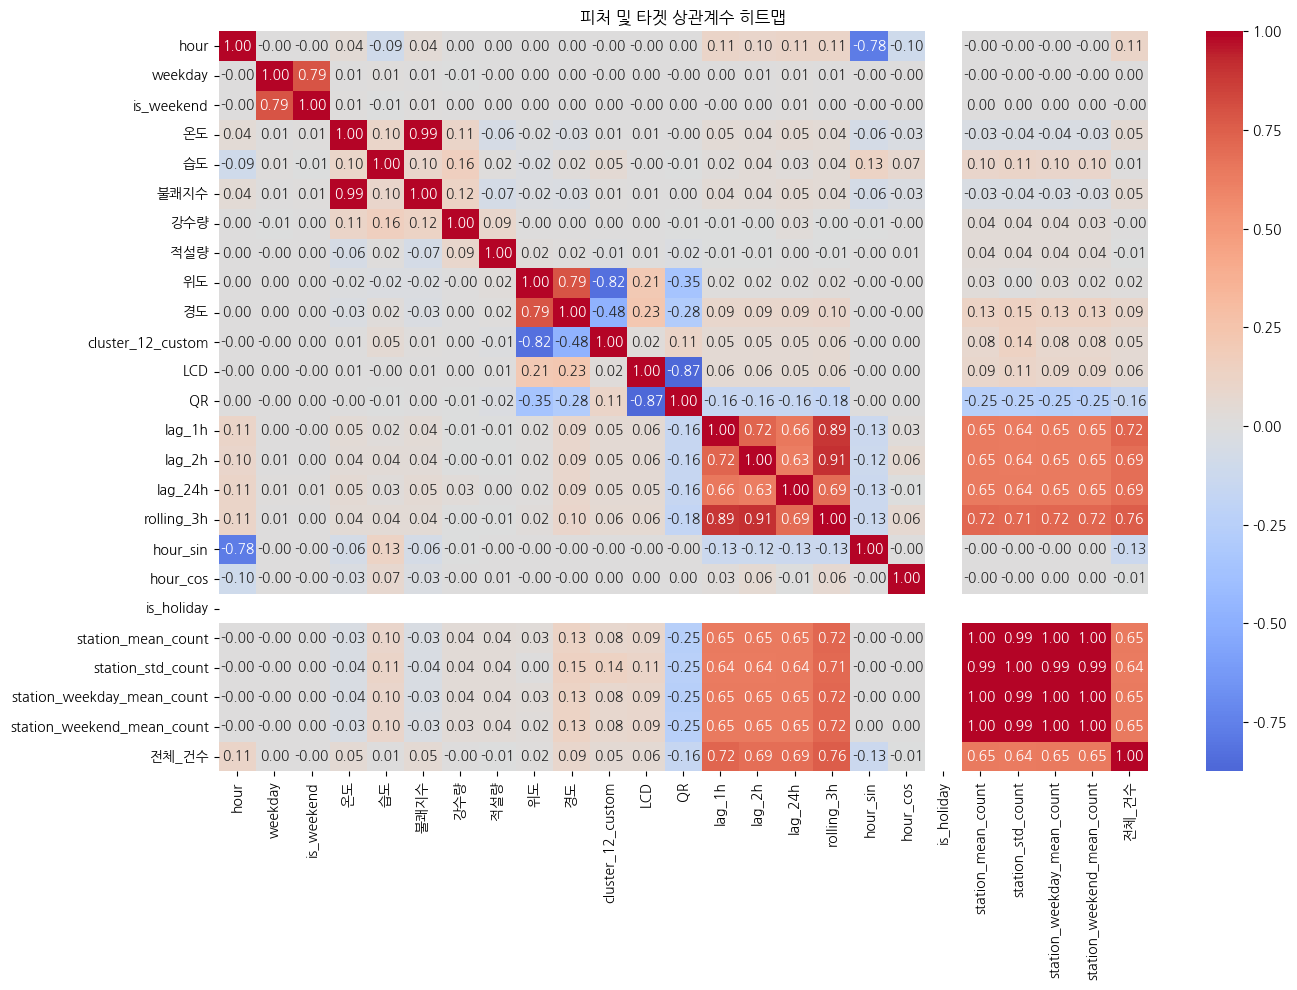

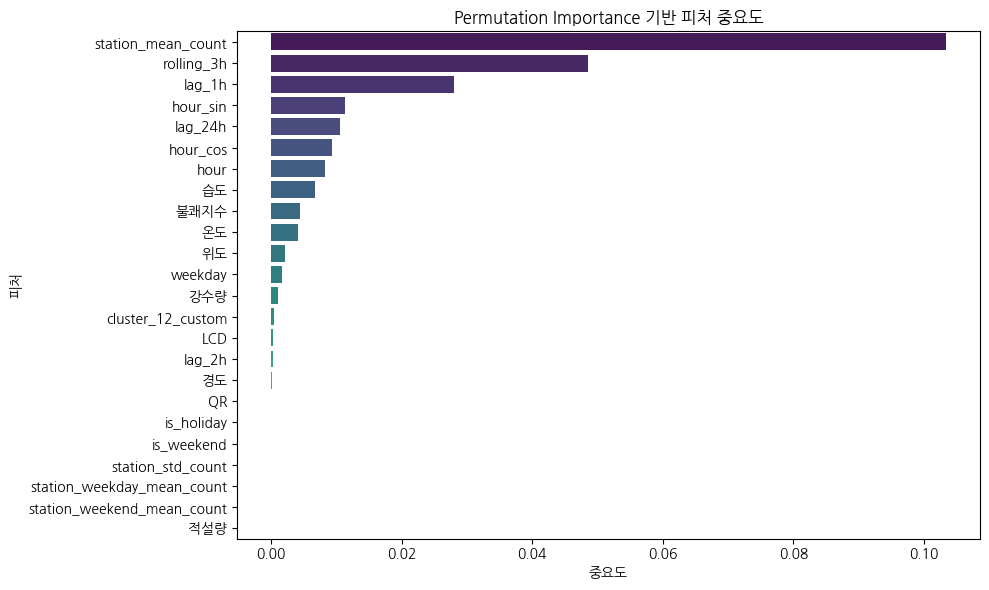

,피처,중요도
20,station_mean_count,0.103393
16,rolling_3h,0.048565
13,lag_1h,0.028065
17,hour_sin,0.011271
15,lag_24h,0.010595
18,hour_cos,0.009337
0,hour,0.008233
4,습도,0.006749
5,불쾌지수,0.004493
3,온도,0.004077


In [15]:
from sklearn.inspection import permutation_importance

# 피처 상관계수 히트맵
corr_cols = features + [target]
corr_df = train[corr_cols].copy()
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('피처 및 타겟 상관계수 히트맵')
plt.tight_layout()
plt.show()

# permutation importance 기반 피처 중요도
perm_result = permutation_importance(
    hgb,
    X_test,
    np.log1p(y_test),
    n_repeats=5,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

importance_df = pd.DataFrame({
    '피처': features,
    '중요도': perm_result.importances_mean
}).sort_values('중요도', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='중요도', y='피처', palette='viridis')
plt.title('Permutation Importance 기반 피처 중요도')
plt.xlabel('중요도')
plt.ylabel('피처')
plt.tight_layout()
plt.show()

display(importance_df)

In [16]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

# 비교용 입력 데이터 정리
X_train_cmp = X_train.fillna(0).copy()
X_test_cmp = X_test.fillna(0).copy()
y_train_log = np.log1p(y_train)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        learning_rate=0.05,
        n_estimators=200,
        max_depth=3,
        random_state=42
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )
}

model_scores = []
model_predictions = {}

for model_name, model in models.items():
    model.fit(X_train_cmp, y_train_log)
    pred_log = model.predict(X_test_cmp)
    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    model_predictions[model_name] = pred
    model_scores.append({
        '모델': model_name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    })

model_score_df = pd.DataFrame(model_scores).sort_values('RMSE')
display(model_score_df)

,모델,MAE,RMSE,R2
5,HistGradientBoosting,0.463992,1.259663,0.672723
3,ExtraTrees,0.469405,1.272246,0.666151
2,RandomForest,0.474473,1.287862,0.657906
4,GradientBoosting,0.488987,1.334539,0.632659
0,LinearRegression,0.550457,1.584837,0.481944
1,Ridge,0.550439,1.585082,0.481784


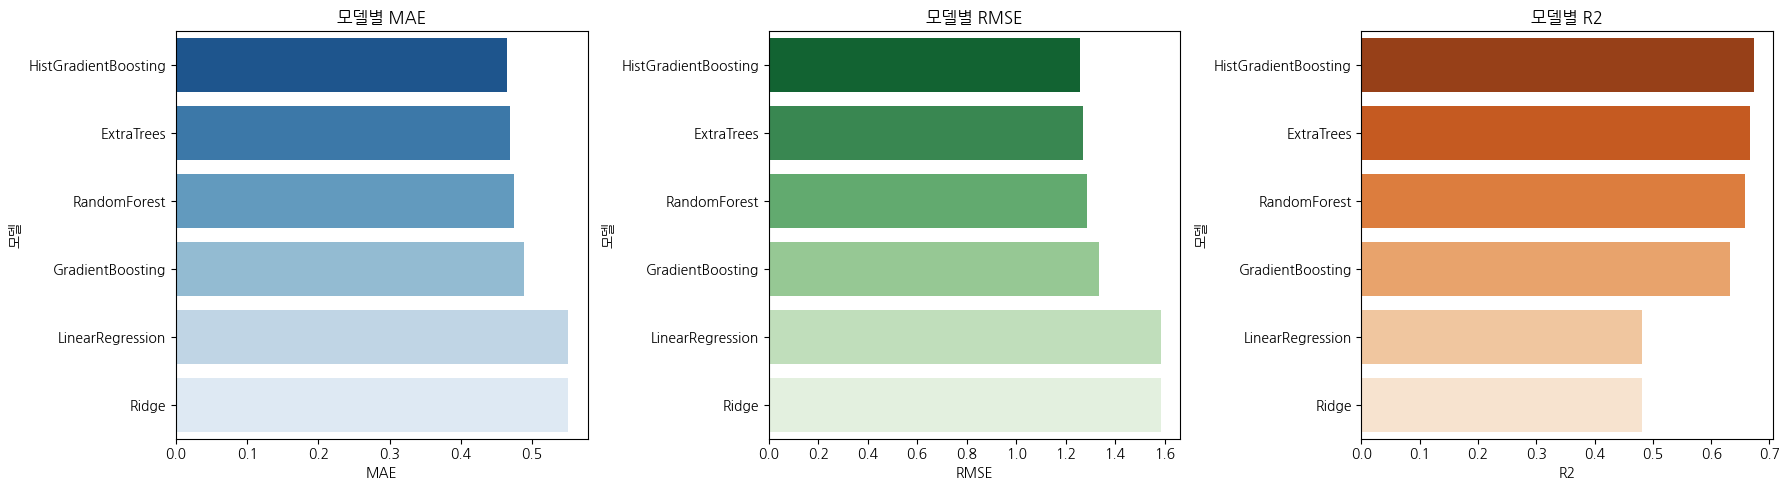

In [17]:
# 모델별 성능 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=model_score_df, x='MAE', y='모델', ax=axes[0], palette='Blues_r')
axes[0].set_title('모델별 MAE')

sns.barplot(data=model_score_df, x='RMSE', y='모델', ax=axes[1], palette='Greens_r')
axes[1].set_title('모델별 RMSE')

sns.barplot(data=model_score_df, x='R2', y='모델', ax=axes[2], palette='Oranges_r')
axes[2].set_title('모델별 R2')

plt.tight_layout()
plt.show()

## 9. 추천 모델: 시간/날씨/구조/lag 기반 HGB


In [18]:
# 추천 분석 방향: station profile 없이, 시간/날씨/구조/lag 기반 HGB
recommended_features = base_features + lag_features

model_df = df_hourly.copy()
model_df['month'] = model_df['datetime'].dt.month

# 2024년 내부 시계열 검증: 1~9월 학습, 10~12월 검증
train_2024 = model_df[model_df['year'] == 2024].copy()
valid_2024 = train_2024[train_2024['month'] >= 10].copy()
subtrain_2024 = train_2024[train_2024['month'] < 10].copy()
test_2025_reco = model_df[model_df['year'] == 2025].copy()

X_subtrain = subtrain_2024[recommended_features].fillna(0)
y_subtrain = subtrain_2024[target]
X_valid = valid_2024[recommended_features].fillna(0)
y_valid = valid_2024[target]
X_test_reco = test_2025_reco[recommended_features].fillna(0)
y_test_reco = test_2025_reco[target]

recommended_hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

recommended_hgb.fit(X_subtrain, np.log1p(y_subtrain))
valid_pred = np.clip(np.expm1(recommended_hgb.predict(X_valid)), 0, None)

validation_result_df = pd.DataFrame({
    '구간': ['2024 holdout (10~12월)'],
    'MAE': [mean_absolute_error(y_valid, valid_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_valid, valid_pred))],
    'R2': [r2_score(y_valid, valid_pred)]
})

# 2024 전체로 다시 학습 후 2025 테스트 평가
recommended_hgb.fit(train_2024[recommended_features].fillna(0), np.log1p(train_2024[target]))
recommended_pred_2025 = np.clip(
    np.expm1(recommended_hgb.predict(X_test_reco)),
    0,
    None
)

test_result_df = pd.DataFrame({
    '구간': ['2025 test'],
    'MAE': [mean_absolute_error(y_test_reco, recommended_pred_2025)],
    'RMSE': [np.sqrt(mean_squared_error(y_test_reco, recommended_pred_2025))],
    'R2': [r2_score(y_test_reco, recommended_pred_2025)]
})

display(pd.concat([validation_result_df, test_result_df], ignore_index=True))
print('추천 피처 수:', len(recommended_features))
print(recommended_features)

,구간,MAE,RMSE,R2
0,2024 holdout (10~12월),0.528649,1.448671,0.685511
1,2025 test,0.466889,1.266731,0.669040


추천 피처 수: 20
['hour', 'weekday', 'is_weekend', '온도', '습도', '불쾌지수', '강수량', '적설량', '위도', '경도', 'cluster_12_custom', 'LCD', 'QR', 'lag_1h', 'lag_2h', 'lag_24h', 'rolling_3h', 'hour_sin', 'hour_cos', 'is_holiday']


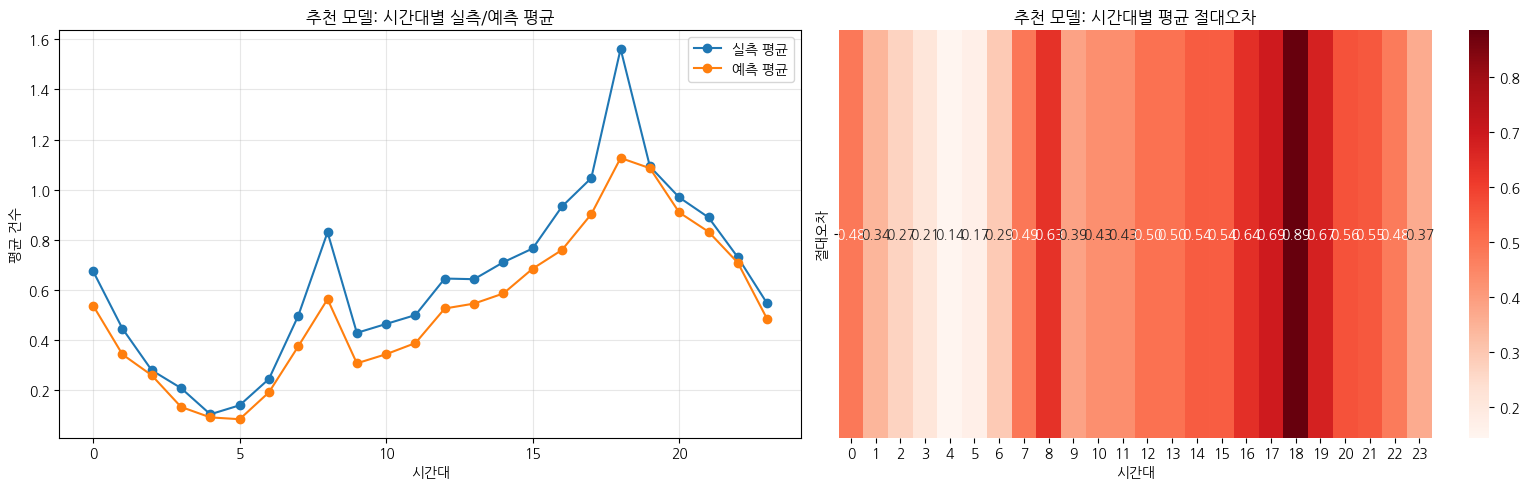

In [19]:
# 추천 모델 결과 시각화
recommended_eval_df = test_2025_reco[['datetime', '시작_대여소_ID', 'hour', '전체_건수']].copy()
recommended_eval_df['예측_건수'] = recommended_pred_2025
recommended_eval_df['절대오차'] = (
    recommended_eval_df['전체_건수'] - recommended_eval_df['예측_건수']
).abs()

recommended_hour_eval = recommended_eval_df.groupby('hour', as_index=False).agg({
    '전체_건수': 'mean',
    '예측_건수': 'mean',
    '절대오차': 'mean'
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(recommended_hour_eval['hour'], recommended_hour_eval['전체_건수'], marker='o', label='실측 평균')
axes[0].plot(recommended_hour_eval['hour'], recommended_hour_eval['예측_건수'], marker='o', label='예측 평균')
axes[0].set_title('추천 모델: 시간대별 실측/예측 평균')
axes[0].set_xlabel('시간대')
axes[0].set_ylabel('평균 건수')
axes[0].legend()
axes[0].grid(alpha=0.3)

sns.heatmap(
    recommended_hour_eval.set_index('hour')[['절대오차']].T,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    ax=axes[1]
)
axes[1].set_title('추천 모델: 시간대별 평균 절대오차')
axes[1].set_xlabel('시간대')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

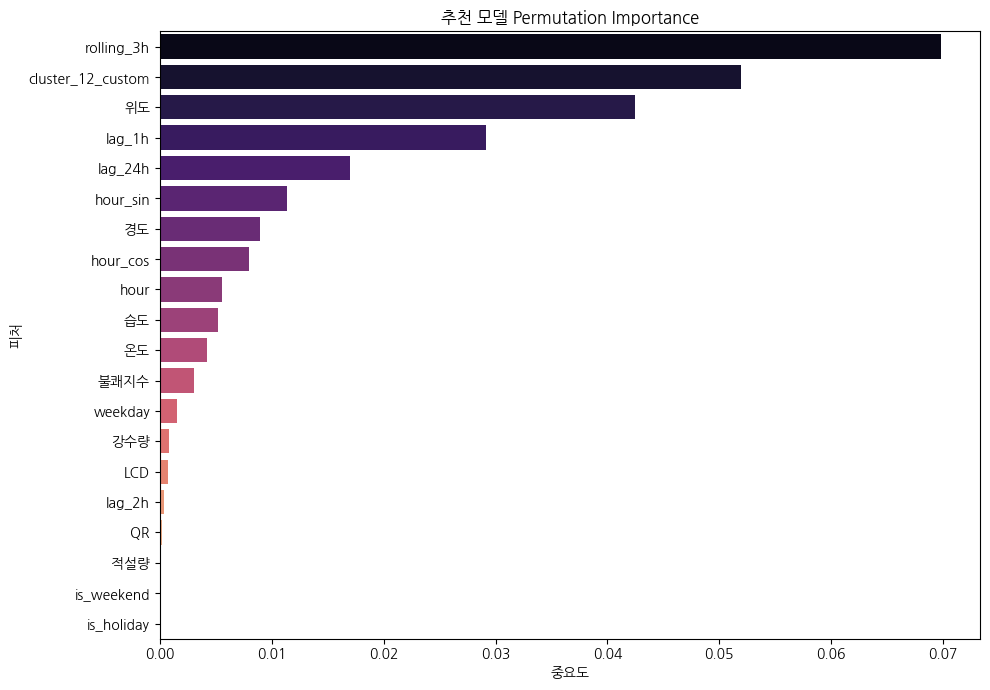

,피처,중요도
16,rolling_3h,0.069801
10,cluster_12_custom,0.051980
8,위도,0.042486
13,lag_1h,0.029144
15,lag_24h,0.017032
17,hour_sin,0.011328
9,경도,0.008993
18,hour_cos,0.007950
0,hour,0.005544
4,습도,0.005247


In [20]:
# 추천 모델 피처 중요도
recommended_perm = permutation_importance(
    recommended_hgb,
    X_test_reco,
    np.log1p(y_test_reco),
    n_repeats=5,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

recommended_importance_df = pd.DataFrame({
    '피처': recommended_features,
    '중요도': recommended_perm.importances_mean
}).sort_values('중요도', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=recommended_importance_df, x='중요도', y='피처', palette='magma')
plt.title('추천 모델 Permutation Importance')
plt.xlabel('중요도')
plt.ylabel('피처')
plt.tight_layout()
plt.show()

display(recommended_importance_df)

## 추천 모델 컬럼 설명

- `hour`: 이용이 발생한 시간대의 시(0~23)
- `weekday`: 요일 숫자. 월요일=0, 일요일=6
- `is_weekend`: 주말 여부. 평일=0, 주말=1
- `온도`: 해당 시간대 기온
- `습도`: 해당 시간대 상대습도
- `불쾌지수`: 온도와 습도로 계산한 체감 불쾌 정도
- `강수량`: 해당 시간대 강수량
- `적설량`: 해당 시간대 적설량
- `위도`: 시작 대여소의 위도
- `경도`: 시작 대여소의 경도
- `cluster_12_custom`: 대여소 군집화 결과 라벨. 비슷한 이용 특성을 가진 대여소 그룹
- `LCD`: 해당 대여소의 LCD 자전거 관련 수량 정보
- `QR`: 해당 대여소의 QR 자전거 관련 수량 정보
- `lag_1h`: 1시간 전 같은 대여소의 전체 대여 건수
- `lag_2h`: 2시간 전 같은 대여소의 전체 대여 건수
- `lag_24h`: 24시간 전 같은 대여소의 전체 대여 건수
- `rolling_3h`: 직전 3시간 대여 건수 평균
- `hour_sin`: 시간대의 주기성을 사인값으로 변환한 피처
- `hour_cos`: 시간대의 주기성을 코사인값으로 변환한 피처
- `is_holiday`: 공휴일 여부. 공휴일=1, 그 외=0

해석 포인트:

- `lag_1h`, `lag_24h`, `rolling_3h`가 높으면 최근 수요 흐름이 중요하다는 뜻입니다.
- `cluster_12_custom`, `위도`, `경도`가 높으면 스테이션의 위치/유형 특성이 중요하다는 뜻입니다.
- `hour`, `hour_sin`, `hour_cos`가 높으면 시간대 패턴이 중요하다는 뜻입니다.
- 날씨 관련 컬럼 중요도가 높으면 기상 조건이 수요 변화에 영향을 준다는 뜻입니다.

## 10. 범주형 처리 실험


In [21]:
# 범주형 처리 실험: cluster_12_custom 원핫인코딩 여부 비교
recommended_ohe_train = train_2024[recommended_features].copy()
recommended_ohe_test = test_2025_reco[recommended_features].copy()

cluster_ohe_train = pd.get_dummies(recommended_ohe_train, columns=['cluster_12_custom'], prefix='cluster', dummy_na=False)
cluster_ohe_test = pd.get_dummies(recommended_ohe_test, columns=['cluster_12_custom'], prefix='cluster', dummy_na=False)
cluster_ohe_train, cluster_ohe_test = cluster_ohe_train.align(cluster_ohe_test, join='left', axis=1, fill_value=0)

cluster_ohe_model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

cluster_ohe_model.fit(cluster_ohe_train.fillna(0), np.log1p(train_2024[target]))
cluster_ohe_pred = np.clip(np.expm1(cluster_ohe_model.predict(cluster_ohe_test.fillna(0))), 0, None)

cluster_compare_df = pd.DataFrame({
    '모델 버전': ['추천 모델(숫자형 cluster)', '추천 모델(cluster 원핫)'],
    'MAE': [
        mean_absolute_error(y_test_reco, recommended_pred_2025),
        mean_absolute_error(y_test_reco, cluster_ohe_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_reco, recommended_pred_2025)),
        np.sqrt(mean_squared_error(y_test_reco, cluster_ohe_pred))
    ],
    'R2': [
        r2_score(y_test_reco, recommended_pred_2025),
        r2_score(y_test_reco, cluster_ohe_pred)
    ]
})

display(cluster_compare_df)

,모델 버전,MAE,RMSE,R2
0,추천 모델(숫자형 cluster),0.466889,1.266731,0.669040
1,추천 모델(cluster 원핫),0.466497,1.264352,0.670282


## 최종 권장 파이프라인 정리

현재 노트북 기준 최종 권장 파이프라인은 아래와 같습니다.

1. `2024_data`, `2025_data`를 합친 뒤 선택한 스테이션만 필터링합니다.
2. `기준_날짜 + 시간대`를 기준으로 스테이션별 시간 패널 데이터를 만듭니다.
3. 비어 있는 시간대는 `전체_건수=0`으로 채우고, 날씨는 `ffill/bfill`로 보완합니다.
4. 시간 피처(`hour`, `weekday`, `is_weekend`, `is_holiday`, `hour_sin`, `hour_cos`)를 생성합니다.
5. 최근 수요 피처(`lag_1h`, `lag_2h`, `lag_24h`, `rolling_3h`)를 생성합니다.
6. 스테이션 구조 피처(`위도`, `경도`, `cluster_12_custom`, `LCD`, `QR`)를 붙입니다.
7. 스테이션 평균 수요(`station_mean_count`) 같은 강한 고정효과 피처는 추천 모델에서 제외합니다.
8. 모델은 `HistGradientBoostingRegressor`를 사용하고, 타깃은 `log1p(전체_건수)`로 학습합니다.
9. 검증은 `2024년 1~9월 학습, 10~12월 검증`과 `2024 전체 학습, 2025 테스트` 두 단계로 봅니다.

해석상 핵심은 다음입니다.

- 이 모델은 `최근 수요 흐름 + 시간대 패턴 + 스테이션 위치/유형`을 바탕으로 예측합니다.
- 따라서 운영상 "어느 스테이션에 몇 대가 필요할지"를 보기 위한 방향으로는 적절합니다.
- 다만 `cluster`를 숫자형으로 둘지 원핫인코딩할지는 비교 결과를 보고 선택하는 것이 좋습니다.

## 11. 월별 유사도 점검 및 삭제 원칙

월별 데이터가 비슷하다고 해서 자동으로 삭제하지는 않습니다.

- `완전 중복`은 제거 대상입니다.
- `유사한 월`은 계절성 또는 정상적인 반복 패턴일 수 있으므로 기본적으로 유지합니다.
- 대신 월별 유사도를 계산해서, 너무 비슷한 월 조합이 있는지 확인하고 필요 시 별도 판단합니다.


,항목,값
0,패널 중복 행 수,0


,month,전체_건수,lag_1h,lag_24h,rolling_3h,온도,습도,불쾌지수,강수량,적설량
0,1,6119.0,0.472994,0.467130,0.472814,-0.748048,61.090664,36.643645,93.3,43.89
1,2,6503.0,0.519397,0.515645,0.518731,2.356130,71.507184,39.540425,235.6,94.08
2,3,9288.0,0.693026,0.688396,0.692926,5.818100,61.973566,45.533215,371.5,109.83
3,4,13529.0,1.043133,1.031713,1.041487,13.840239,59.175772,56.333957,190.3,0.00
4,5,13133.0,0.980809,0.982826,0.981979,16.782669,64.679435,60.732078,306.1,0.00
5,6,13818.0,1.066590,1.085571,1.066178,23.340741,57.547917,69.661859,820.0,0.00
6,7,8305.0,0.619997,0.613351,0.619698,25.209065,79.918981,75.009617,4015.0,0.00
7,8,10802.0,0.805182,0.801747,0.805979,27.710506,80.749477,79.111860,2553.9,0.00
8,9,11775.0,0.908719,0.906404,0.908282,24.829375,75.415201,73.997395,1367.2,0.00
9,10,14354.0,1.072655,1.069892,1.073004,16.494878,70.319444,60.770313,199.2,0.00


month,1,2,3,4,5,6,7,8,9,10,11,12
month,,,,,,,,,,,,
1,1.000000,0.999753,0.999677,0.999956,0.999927,0.998986,0.906824,0.976535,0.994935,0.999958,0.999969,0.999950
2,0.999753,1.000000,0.999979,0.999626,0.999792,0.999605,0.915388,0.980753,0.996735,0.999626,0.999600,0.999482
3,0.999677,0.999979,1.000000,0.999592,0.999789,0.999740,0.916921,0.981517,0.997071,0.999588,0.999542,0.999387
4,0.999956,0.999626,0.999592,1.000000,0.999957,0.998978,0.906333,0.976302,0.994846,1.000000,0.999993,0.999951
5,0.999927,0.999792,0.999789,0.999957,1.000000,0.999353,0.910202,0.978263,0.995742,0.999955,0.999929,0.999839
6,0.998986,0.999605,0.999740,0.998978,0.999353,1.000000,0.924504,0.985085,0.998411,0.998969,0.998860,0.998574
7,0.906824,0.915388,0.916921,0.906333,0.910202,0.924504,1.000000,0.976301,0.944503,0.906256,0.905301,0.902997
8,0.976535,0.980753,0.981517,0.976302,0.978263,0.985085,0.976301,1.000000,0.993213,0.976263,0.975773,0.974573
9,0.994935,0.996735,0.997071,0.994846,0.995742,0.998411,0.944503,0.993213,1.000000,0.994828,0.994596,0.994014


,월1,월2,유사도
29,4,10,1.000000
46,10,11,0.999995
30,4,11,0.999993
48,11,12,0.999980
9,2,3,0.999979
7,1,11,0.999969
6,1,10,0.999958
26,4,5,0.999957
2,1,4,0.999956
34,5,10,0.999955


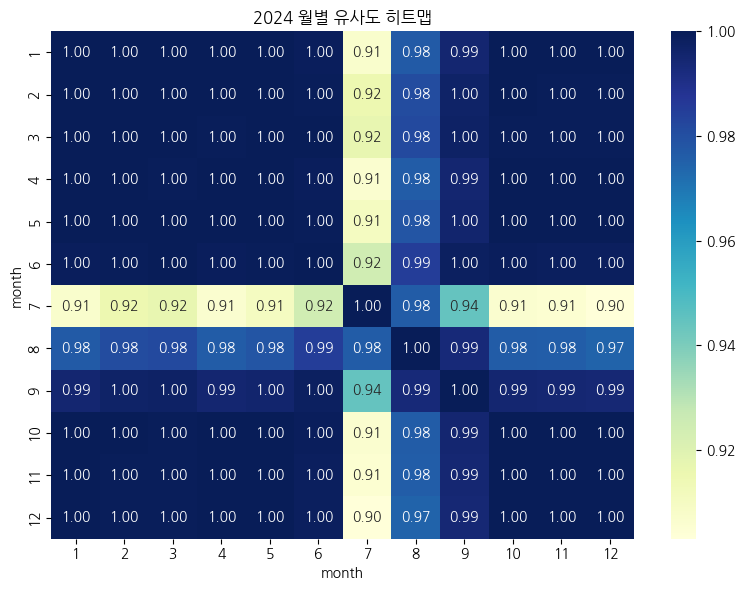

In [22]:
# 월별 유사도 점검: 비슷한 월은 리포트만 하고 기본적으로 삭제하지 않음
from sklearn.metrics.pairwise import cosine_similarity
panel_duplicate_count = df_hourly.duplicated(subset=['시작_대여소_ID', 'datetime']).sum()

monthly_check_df = train_2024.copy()
monthly_check_df['month'] = monthly_check_df['datetime'].dt.month
monthly_summary = monthly_check_df.groupby('month', as_index=False).agg({
    '전체_건수': 'sum',
    'lag_1h': 'mean',
    'lag_24h': 'mean',
    'rolling_3h': 'mean',
    '온도': 'mean',
    '습도': 'mean',
    '불쾌지수': 'mean',
    '강수량': 'sum',
    '적설량': 'sum'
})

monthly_feature_cols = ['전체_건수', 'lag_1h', 'lag_24h', 'rolling_3h', '온도', '습도', '불쾌지수', '강수량', '적설량']
monthly_similarity = pd.DataFrame(
    cosine_similarity(monthly_summary[monthly_feature_cols]),
    index=monthly_summary['month'],
    columns=monthly_summary['month']
)

high_similarity_pairs = []
for i, month_i in enumerate(monthly_similarity.index):
    for j, month_j in enumerate(monthly_similarity.columns):
        if j <= i:
            continue
        sim = monthly_similarity.loc[month_i, month_j]
        if sim >= 0.98:
            high_similarity_pairs.append({'월1': int(month_i), '월2': int(month_j), '유사도': float(sim)})

high_similarity_df = pd.DataFrame(high_similarity_pairs).sort_values('유사도', ascending=False) if high_similarity_pairs else pd.DataFrame(columns=['월1', '월2', '유사도'])

display(pd.DataFrame({'항목': ['패널 중복 행 수'], '값': [int(panel_duplicate_count)]}))
display(monthly_summary)
display(monthly_similarity)
display(high_similarity_df)

plt.figure(figsize=(8, 6))
sns.heatmap(monthly_similarity, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('2024 월별 유사도 히트맵')
plt.tight_layout()
plt.show()


## 12. 2024 Train/Valid, 2025 Test 기반 모델 튜닝 및 비교

이 섹션에서는 아래 원칙으로 모델을 선택합니다.

- `2024년` 내부에서 여러 시점의 rolling/expanding validation을 사용합니다.
- 특정 몇 개 월만 valid로 두는 단일 split은 계절성 편향이 커질 수 있으므로, 여러 fold 평균 성능으로 선택합니다.
- `2025년 전체`는 최종 일반화 테스트(test)로만 사용합니다.

추천 피처(`base_features + lag_features`)만 사용하고, 여러 모델을 비교한 뒤 rolling validation 평균 성능 기준 최적 파라미터를 선택합니다.


In [23]:
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from ast import literal_eval

# 최종 비교용 데이터셋 정의
final_features = base_features + lag_features
final_test = model_df[model_df['year'] == 2025].copy()
X_final_test = final_test[final_features].fillna(0)
y_final_test = final_test[target]

# 2024 내부 rolling/expanding validation fold 정의
validation_folds = [
    {'fold': 'Fold1', 'train_month_end': 3, 'valid_months': [4, 5]},
    {'fold': 'Fold2', 'train_month_end': 5, 'valid_months': [6, 7]},
    {'fold': 'Fold3', 'train_month_end': 7, 'valid_months': [8, 9]},
    {'fold': 'Fold4', 'train_month_end': 9, 'valid_months': [10, 11, 12]}
]

search_space = {
    'Ridge': {
        'model_class': Pipeline,
        'pipeline_steps': [('scaler', StandardScaler()), ('model', Ridge())],
        'param_grid': {
            'model__alpha': [0.1, 1.0, 10.0, 30.0]
        }
    },
    'RandomForest': {
        'model_class': RandomForestRegressor,
        'fixed_params': {'random_state': 42, 'n_jobs': -1},
        'param_grid': {
            'n_estimators': [200],
            'max_depth': [8, 12, None],
            'min_samples_leaf': [1, 5, 10]
        }
    },
    'ExtraTrees': {
        'model_class': ExtraTreesRegressor,
        'fixed_params': {'random_state': 42, 'n_jobs': -1},
        'param_grid': {
            'n_estimators': [200],
            'max_depth': [8, 12, None],
            'min_samples_leaf': [1, 5, 10]
        }
    },
    'GradientBoosting': {
        'model_class': GradientBoostingRegressor,
        'fixed_params': {'random_state': 42},
        'param_grid': {
            'learning_rate': [0.03, 0.05],
            'n_estimators': [150, 250],
            'max_depth': [2, 3]
        }
    },
    'HistGradientBoosting': {
        'model_class': HistGradientBoostingRegressor,
        'fixed_params': {'random_state': 42},
        'param_grid': {
            'learning_rate': [0.03, 0.05],
            'max_iter': [300, 500],
            'max_depth': [6, 8, 10],
            'min_samples_leaf': [10, 20],
            'l2_regularization': [0.0, 0.1]
        }
    }
}

validation_search_results = []

for model_name, cfg in search_space.items():
    for params in ParameterGrid(cfg['param_grid']):
        fold_scores = []

        for fold_cfg in validation_folds:
            fold_train = model_df[(model_df['year'] == 2024) & (model_df['month'] <= fold_cfg['train_month_end'])].copy()
            fold_valid = model_df[(model_df['year'] == 2024) & (model_df['month'].isin(fold_cfg['valid_months']))].copy()

            X_fold_train = fold_train[final_features].fillna(0)
            y_fold_train = fold_train[target]
            X_fold_valid = fold_valid[final_features].fillna(0)
            y_fold_valid = fold_valid[target]

            if len(fold_train) == 0 or len(fold_valid) == 0:
                continue

            if cfg['model_class'] is Pipeline:
                model = cfg['model_class'](cfg['pipeline_steps'])
                model.set_params(**params)
            else:
                all_params = {}
                all_params.update(cfg.get('fixed_params', {}))
                all_params.update(params)
                model = cfg['model_class'](**all_params)

            model.fit(X_fold_train, np.log1p(y_fold_train))
            valid_pred = np.clip(np.expm1(model.predict(X_fold_valid)), 0, None)
            fold_scores.append({
                'fold': fold_cfg['fold'],
                'mae': mean_absolute_error(y_fold_valid, valid_pred),
                'rmse': np.sqrt(mean_squared_error(y_fold_valid, valid_pred)),
                'r2': r2_score(y_fold_valid, valid_pred)
            })

        if len(fold_scores) == 0:
            continue

        validation_search_results.append({
            '모델': model_name,
            '파라미터': str(params),
            'Avg_Valid_MAE': float(np.mean([x['mae'] for x in fold_scores])),
            'Avg_Valid_RMSE': float(np.mean([x['rmse'] for x in fold_scores])),
            'Avg_Valid_R2': float(np.mean([x['r2'] for x in fold_scores])),
            '사용_Fold수': len(fold_scores)
        })

validation_result_table = pd.DataFrame(validation_search_results).sort_values(['Avg_Valid_RMSE', 'Avg_Valid_MAE'])
best_validation_table = validation_result_table.groupby('모델', as_index=False).first().sort_values('Avg_Valid_RMSE')

display(best_validation_table)
print('검증 기준 최고 모델:', best_validation_table.iloc[0]['모델'])
print('검증 기준 최고 파라미터:', best_validation_table.iloc[0]['파라미터'])


,모델,파라미터,Avg_Valid_MAE,Avg_Valid_RMSE,Avg_Valid_R2,사용_Fold수
0,ExtraTrees,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.599476,1.604333,0.680982,4
2,HistGradientBoosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.598995,1.614026,0.676878,4
3,RandomForest,"{'max_depth': None, 'min_samples_leaf': 10, 'n...",0.613266,1.621626,0.673900,4
1,GradientBoosting,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.655367,1.663569,0.656459,4
4,Ridge,{'model__alpha': 30.0},1.096151,7.806919,-7.889427,4


검증 기준 최고 모델: ExtraTrees
검증 기준 최고 파라미터: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}


In [24]:
# rolling validation에서 고른 최적 모델을 2024 전체로 재학습 후 2025 테스트 평가
best_model_name = best_validation_table.iloc[0]['모델']
best_param_text = best_validation_table.iloc[0]['파라미터']

best_cfg = search_space[best_model_name]
best_params = literal_eval(best_param_text)

if best_cfg['model_class'] is Pipeline:
    final_best_model = best_cfg['model_class'](best_cfg['pipeline_steps'])
    final_best_model.set_params(**best_params)
else:
    final_param_dict = {}
    final_param_dict.update(best_cfg.get('fixed_params', {}))
    final_param_dict.update(best_params)
    final_best_model = best_cfg['model_class'](**final_param_dict)

X_2024_full = model_df[model_df['year'] == 2024][final_features].fillna(0)
y_2024_full = model_df[model_df['year'] == 2024][target]

final_best_model.fit(X_2024_full, np.log1p(y_2024_full))
final_test_pred = np.clip(np.expm1(final_best_model.predict(X_final_test)), 0, None)

final_test_result_df = pd.DataFrame({
    '최종 선택 모델': [best_model_name],
    '최종 파라미터': [best_param_text],
    'Test_MAE': [mean_absolute_error(y_final_test, final_test_pred)],
    'Test_RMSE': [np.sqrt(mean_squared_error(y_final_test, final_test_pred))],
    'Test_R2': [r2_score(y_final_test, final_test_pred)]
})

display(final_test_result_df)


,최종 선택 모델,최종 파라미터,Test_MAE,Test_RMSE,Test_R2
0,ExtraTrees,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.470489,1.269709,0.667482


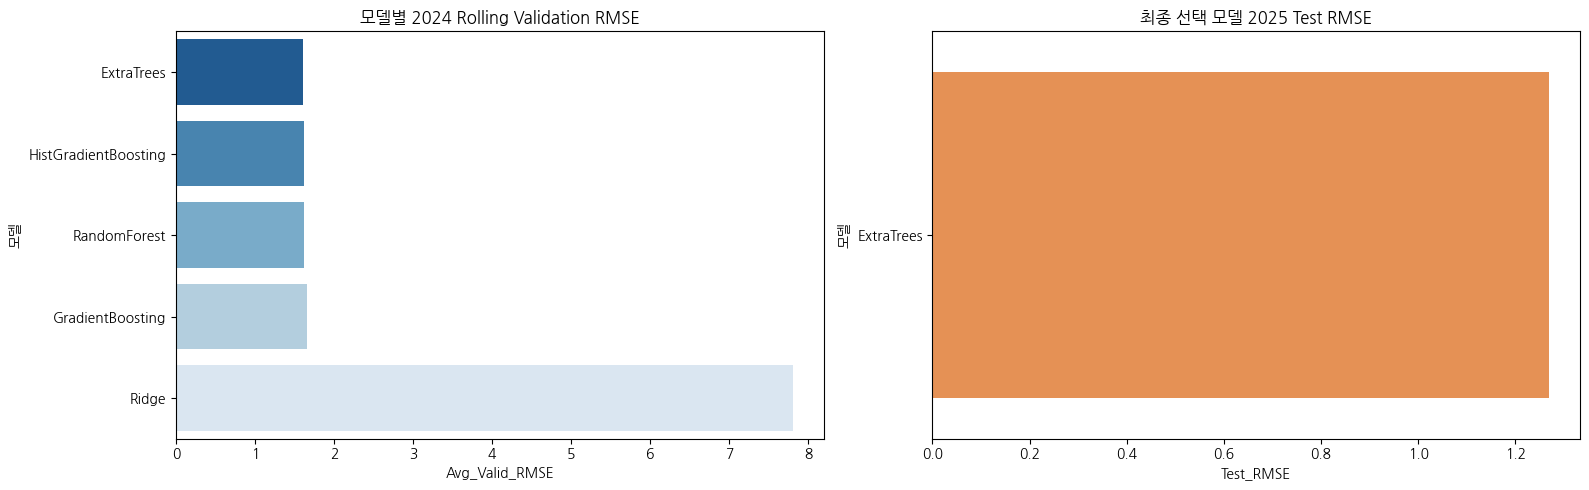

In [25]:
# 모델별 rolling valid / test 성능 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=best_validation_table, x='Avg_Valid_RMSE', y='모델', ax=axes[0], palette='Blues_r')
axes[0].set_title('모델별 2024 Rolling Validation RMSE')

plot_test_df = final_test_result_df.copy()
plot_test_df['모델'] = plot_test_df['최종 선택 모델']
sns.barplot(data=plot_test_df, x='Test_RMSE', y='모델', ax=axes[1], palette='Oranges_r')
axes[1].set_title('최종 선택 모델 2025 Test RMSE')

plt.tight_layout()
plt.show()


## 13. 실무 해석 메모

- 월별 유사도가 높더라도 기본적으로는 삭제하지 않습니다. 이는 계절성과 반복 패턴일 가능성이 높기 때문입니다.
- 삭제 대상은 `완전 중복` 또는 명백한 데이터 오류입니다.
- 최종 모델 선택은 `2024 rolling validation 평균 성능`으로 하고, 일반화 평가는 `2025 test`로 확인합니다.
- 여러 모델을 비교하되, 최종 운영 모델은 해석성과 안정성을 함께 고려해 선택합니다.
